In [2]:
import os
import random
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

from src.ArtificialTrainDataGenerator import ArtificialTrainDataGenerator
from src.FeatureEnhancer import FeatureEnhancer
from src.Elements import Elements

N_SAMPLES = 1000
SAMPLE_PER_ELEMENT = 3
SIGMA_RANGE = (0.2, 0.8)
MU_LOCAL_ERR = 0.05
MU_GLOBAL_ERR = 0.1
OUTPUT_DIR = "data/training_data/artificial"
SPECTRA_PATH = "data/objects/pigment_palette/2_subtracted_residual_spectra_heuristic.npz"

X, y = ArtificialTrainDataGenerator.generate_dataset(
    N_SAMPLES,
    mu_local_err=MU_LOCAL_ERR,
    mu_global_err=MU_GLOBAL_ERR,
    sigma_range=SIGMA_RANGE,
    set_perc=True,
    use_cache=False
)
print(y[0].tolist())


Generating Samples: 100%|██████████| 1000/1000 [00:00<00:00, 1403.39it/s]


[0.0, 18.004647637345435, 28.92484173082413, 0.0, 6.9692989831614085, 0.0, 0.0, 5.376675271106018, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 19.789412198072625, 0.0, 945.905881251282]


In [5]:
X = FeatureEnhancer.process_spectra(np.array(X))

100%|██████████| 1/1 [00:00<00:00, 10866.07it/s]


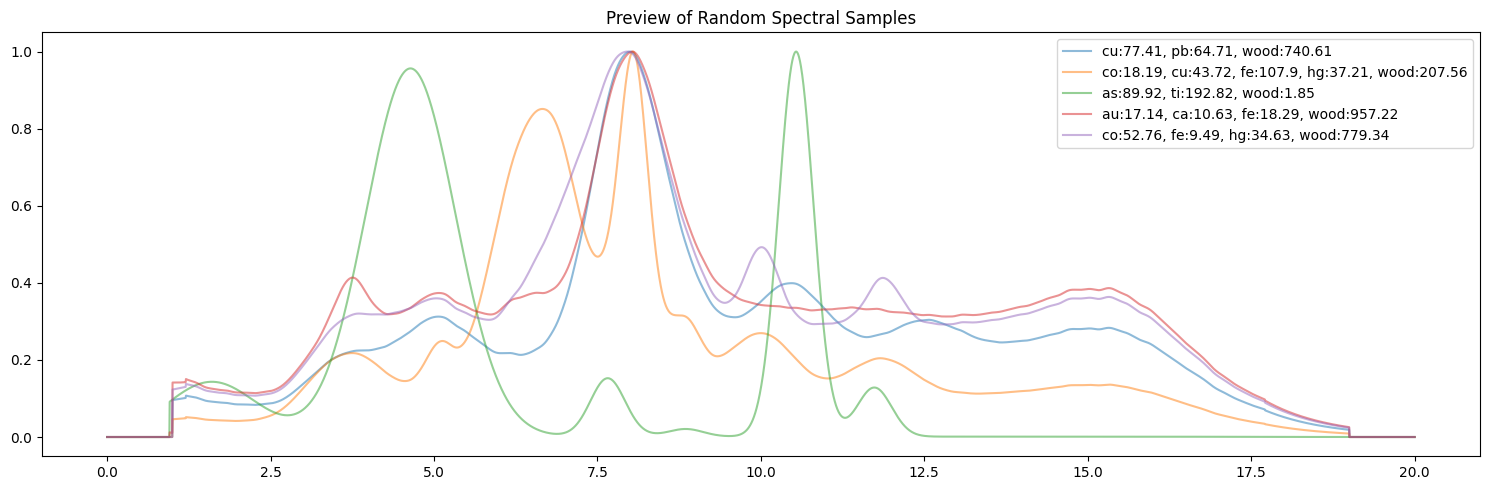

In [4]:
def preview_random_samples(X, y, n=5):
    plt.figure(figsize=(15, 5))
    for _ in range(n):
        i = random.randint(0, len(y) - 1)
        label = ", ".join([
            f"{Elements.NUM2SYMBOL[j] if j < len(Elements.NUM2SYMBOL) else 'wood'}:{round(el, 2)}"
            for j, el in enumerate(y[i]) if el > 0
        ])
        plt.plot(np.linspace(0, 20, 4096), X[i], alpha=0.5, label=label if _ < 10 else "")
    plt.legend()
    plt.title("Preview of Random Spectral Samples")
    plt.tight_layout()
    plt.show()

preview_random_samples(X, y)

In [7]:
# === Save Output ===
def save_data(X, y, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    np.save(os.path.join(output_dir, f"X_regression_{timestamp}.npy"), X)
    np.save(os.path.join(output_dir, f"y_regression_{timestamp}.npy"), y)
    print(f"Data saved in '{output_dir}' with timestamp {timestamp}")

save_data(X, y, OUTPUT_DIR)

Data saved in 'data/training_data/artificial' with timestamp 20250530_000140
